# Model Comparison, Hypothesis Testing & SHAP Analysis

**Part 1**: TimeSeriesSplit 5-fold CV for model comparison (AUC CI + rankings)  
**Part 2**: SHAP feature importance — CatBoost / XGBoost / LightGBM (temporal split, best params)

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import shap

from logistics_delay.data.loader import load_processed
from logistics_delay.features.engineering import XGB_CAT_COLS, FEATURES_ENC, FEATURES_XGB
from logistics_delay.models.evaluate import get_model
from logistics_delay.models.comparison import run_comparison, _create_model, _select_features
from logistics_delay.interpretation.shap_analysis import compute_shap_importance
from logistics_delay.utils.paths import FIGURES_SHAP, FIGURES_MODELS, TABLES_DIR, ensure_output_dirs

warnings.filterwarnings('ignore')

# ── Publication style ──────────────────────────
PALETTE = {
    "blue_main": "#0F4D92", "blue_secondary": "#3775BA",
    "green_1": "#DDF3DE", "green_2": "#AADCA9", "green_3": "#8BCF8B",
    "red_1": "#F6CFCB", "red_2": "#E9A6A1", "red_strong": "#B64342",
    "neutral": "#CFCECE", "highlight": "#FFD700",
    "teal": "#42949E", "violet": "#9A4D8E",
}

plt.rcParams.update({
    "font.family": ["Arial", "SimHei", "DejaVu Sans", "sans-serif"],
    "font.size": 15,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 2.5,
    "legend.frameon": False,
    "svg.fonttype": "none",
})
plt.rcParams['axes.unicode_minus'] = False
ensure_output_dirs()
print('[OK] Imports complete')

[OK] Imports complete


In [2]:
# ── Load pre-processed data (skip raw → engineer_features) ──
df = load_processed()
X_enc = df[FEATURES_ENC]
y = df['Answer']
print(f'Data shape: {df.shape}')
print(f'Delay rate: {y.mean()*100:.1f}%')

[loader] Preprocessed data loaded: (6854, 54)
[loader] Delay rate: 63.19%
Data shape: (6854, 54)
Delay rate: 63.2%


---
## Model Comparison & Hypothesis Testing

**TimeSeriesSplit 5-fold** temporal CV with Bootstrap AUC confidence intervals and cross-fold ranking analysis.

In [3]:
# ════════════════════════════════════════════════════════════════
#  1. TimeSeriesSplit 5-fold temporal CV
# ════════════════════════════════════════════════════════════════
results = run_comparison(df, n_bootstrap=2000)

auc_ci = results['auc_ci']
rankings_df = results['rankings_df']
win_matrix = results['win_matrix']
fold_aucs = results['fold_aucs']
fold_details = results['fold_details']

[comparison] TimeSeriesSplit(5) → 5 temporal folds
[comparison] Models: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']
[comparison] Bootstrap: 2000

  [fold_1]  train=1144  test=1142  spw=8.1520
    LogisticRegression    AUC=0.3175  95%CI=[0.2347, 0.4251]
    DecisionTree          AUC=0.5000  95%CI=[0.5000, 0.5000]
    RandomForest          AUC=0.6266  95%CI=[0.5702, 0.6882]
    XGBoost               AUC=0.2901  95%CI=[0.2521, 0.3296]
    LightGBM              AUC=0.4450  95%CI=[0.3826, 0.5239]
    CatBoost              AUC=0.4016  95%CI=[0.3666, 0.4397]

  [fold_2]  train=2286  test=1142  spw=0.8201
    LogisticRegression    AUC=0.5336  95%CI=[0.3591, 0.7112]
    DecisionTree          AUC=0.6039  95%CI=[0.4582, 0.7464]
    RandomForest          AUC=0.6338  95%CI=[0.5126, 0.7608]
    XGBoost               AUC=0.7372  95%CI=[0.6232, 0.8352]
    LightGBM              AUC=0.6855  95%CI=[0.5658, 0.7921]
    CatBoost              AUC=0.6586  95%CI=

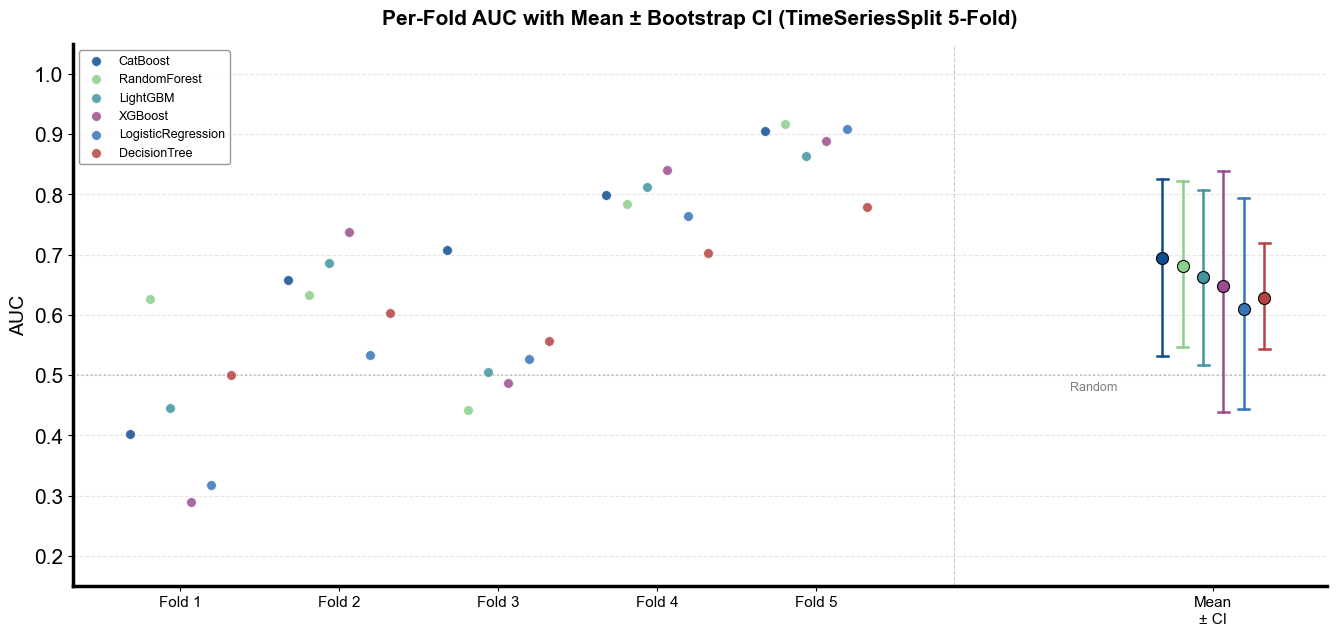

[OK] Saved → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\per_fold_auc_scatter.png

Model                   Mean AUC  CI Lower  CI Upper
----------------------------------------------------
CatBoost                  0.6943    0.5326    0.8257
RandomForest              0.6808    0.5475    0.8224
LightGBM                  0.6624    0.5172    0.8075
XGBoost                   0.6486    0.4394    0.8392
LogisticRegression        0.6103    0.4431    0.7935
DecisionTree              0.6287    0.5436    0.7197

[OK] Pooled Bootstrap CI → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\tables\auc_fold_bootstrap_ci.csv


In [4]:
# ════════════════════════════════════════════════════════════════
#  Fig 1: Per-fold AUC scatter + mean (pooled Bootstrap CI)
# ════════════════════════════════════════════════════════════════
model_order = rankings_df.sort_values('avg_rank').index.tolist()

model_colors = {
    'CatBoost':          PALETTE['blue_main'],
    'RandomForest':      PALETTE['green_3'],
    'LightGBM':          PALETTE['teal'],
    'XGBoost':           PALETTE['violet'],
    'LogisticRegression': PALETTE['blue_secondary'],
    'DecisionTree':      PALETTE['red_strong'],
}

n_folds = fold_aucs.shape[0]
n_models = len(model_order)

# ── Pooled Bootstrap CI for mean ──
rng_boot = np.random.default_rng(2024)
n_boot = 5000
mean_ci_records = []
for m in model_order:
    vals = fold_aucs[m].dropna().values
    boot_means = np.array([np.mean(rng_boot.choice(vals, size=len(vals), replace=True))
                           for _ in range(n_boot)])
    mean_ci_records.append({
        "model": m,
        "mean_auc": float(np.mean(vals)),
        "ci_lower": float(np.percentile(boot_means, 2.5)),
        "ci_upper": float(np.percentile(boot_means, 97.5)),
    })
mean_ci_df = pd.DataFrame(mean_ci_records)

# ── Plot ──
fig, ax = plt.subplots(figsize=(14, 7))

fold_labels = [f"Fold {i+1}" for i in range(n_folds)]
x_folds = np.arange(n_folds)
x_extra = np.array([n_folds + 1.5])  # mean column x-position

offset = 0.32
offsets = np.linspace(-offset, offset, n_models)

for i, m in enumerate(model_order):
    c = model_colors[m]
    vals = fold_aucs[m].values
    o = offsets[i]

    # Left: 5-fold scatter
    ax.scatter(x_folds + o, vals, color=c, edgecolors='white',
               linewidth=0.6, s=50, zorder=5, alpha=0.85, label=m)

    # Right: mean ± pooled Bootstrap CI
    ci = mean_ci_df.loc[mean_ci_df["model"] == m].iloc[0]
    ax.scatter(x_extra + o, ci["mean_auc"], color=c, edgecolors='black',
               linewidth=0.8, s=75, zorder=6)
    ax.plot([x_extra[0] + o, x_extra[0] + o],
            [ci["ci_lower"], ci["ci_upper"]], color=c, linewidth=1.8, zorder=5)
    cap_w = 0.035
    ax.plot([x_extra[0] + o - cap_w, x_extra[0] + o + cap_w],
            [ci["ci_lower"], ci["ci_lower"]], color=c, linewidth=1.8, zorder=5)
    ax.plot([x_extra[0] + o - cap_w, x_extra[0] + o + cap_w],
            [ci["ci_upper"], ci["ci_upper"]], color=c, linewidth=1.8, zorder=5)

ax.set_xticks(list(x_folds) + list(x_extra))
ax.set_xticklabels(fold_labels + ["Mean\n± CI"], fontsize=11)
ax.set_ylabel("AUC", fontsize=14)
ax.set_title("Per-Fold AUC with Mean ± Bootstrap CI (TimeSeriesSplit 5-Fold)",
             fontsize=15, fontweight="bold", pad=14)
ax.set_ylim(0.15, 1.05)
ax.axhline(y=0.5, color="gray", linestyle=":", linewidth=1.2, alpha=0.5)
ax.text(5.6, 0.48, "Random", fontsize=9, color="gray", va="center")
ax.grid(axis="y", linestyle="--", alpha=0.3)

# Separator
ax.axvline(x=n_folds - 0.5 + offset + 0.05, color="gray", linestyle="--",
           linewidth=0.8, alpha=0.4)

ax.legend(loc="upper left", fontsize=9, frameon=True, facecolor="white",
          edgecolor="gray", ncol=1)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / "per_fold_auc_scatter.pdf", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_MODELS / "per_fold_auc_scatter.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"[OK] Saved → {FIGURES_MODELS / 'per_fold_auc_scatter.png'}")
print()

# ── Print numeric table ──
print(f"{'Model':<22s} {'Mean AUC':>9s} {'CI Lower':>9s} {'CI Upper':>9s}")
print("-" * 52)
for _, r in mean_ci_df.iterrows():
    print(f"{r['model']:<22s} {r['mean_auc']:>9.4f} {r['ci_lower']:>9.4f} {r['ci_upper']:>9.4f}")

# Also save numeric values
mean_ci_df.to_csv(TABLES_DIR / "auc_fold_bootstrap_ci.csv", index=False, encoding="utf-8-sig")
print(f"\n[OK] Pooled Bootstrap CI → {TABLES_DIR / 'auc_fold_bootstrap_ci.csv'}")

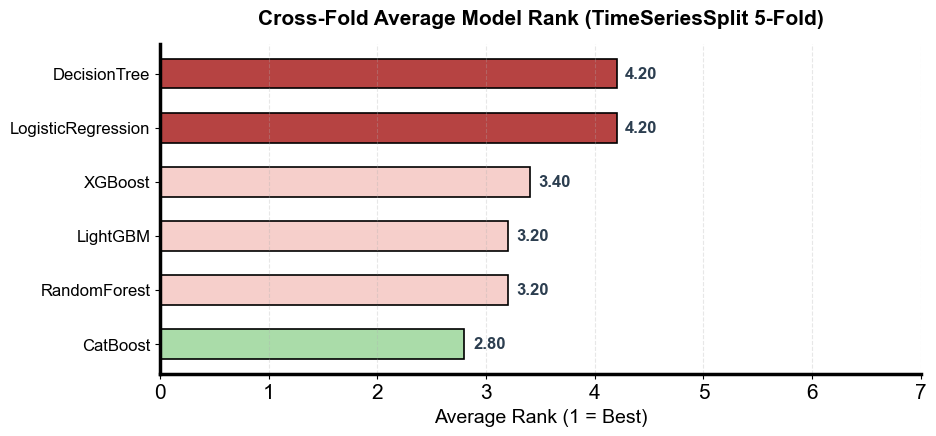

[OK] Saved → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\model_avg_rank.png


In [5]:
# ════════════════════════════════════════════════════════════════
#  Fig 2: Average model rank (lower is better)
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
avg = rankings_df['avg_rank'].sort_values()
n_m = len(avg)

def _rank_color(v):
    if v <= 2: return PALETTE['green_3']
    elif v <= 3: return PALETTE['green_2']
    elif v <= 4: return PALETTE['red_1']
    else: return PALETTE['red_strong']
colors = [_rank_color(v) for v in avg.values]

ax.barh(range(n_m), avg.values, color=colors, edgecolor='black', height=0.55, linewidth=1.2)
ax.set_yticks(range(n_m))
ax.set_yticklabels(avg.index, fontsize=12)
ax.set_xlabel('Average Rank (1 = Best)', fontsize=14)
ax.set_title('Cross-Fold Average Model Rank (TimeSeriesSplit 5-Fold)',
             fontsize=15, fontweight='bold', pad=14)
ax.set_xlim(0, n_m + 1)
ax.grid(axis='x', linestyle='--', alpha=0.3)
for i, v in enumerate(avg.values):
    ax.text(v + 0.08, i, f'{v:.2f}', va='center', fontsize=12, fontweight='bold', color='#2c3e50')

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'model_avg_rank.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'model_avg_rank.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'[OK] Saved → {FIGURES_MODELS / "model_avg_rank.png"}')

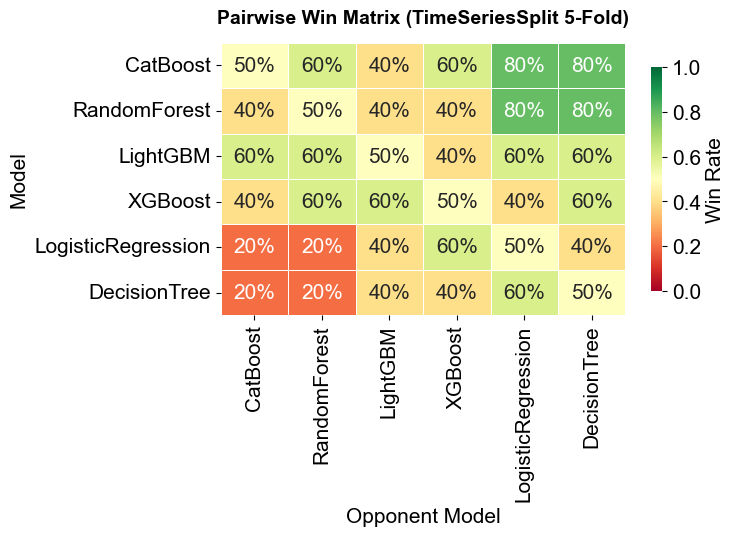

[OK] Saved → C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\figures\models\win_matrix.png


In [6]:
# ════════════════════════════════════════════════════════════════
#  Fig 3: Pairwise win matrix (row beats col, fraction of folds)
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 6))
order = rankings_df.sort_values('avg_rank').index.tolist()
wm_sorted = win_matrix.loc[order, order]  # values are 0-1 decimal
sns.heatmap(wm_sorted, annot=True, fmt='.0%', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Win Rate', 'shrink': 0.82})
ax.set_title('Pairwise Win Matrix (TimeSeriesSplit 5-Fold)', fontsize=14, fontweight='bold', pad=14)
ax.set_ylabel('Model')
ax.set_xlabel('Opponent Model')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig.tight_layout(pad=2)
fig.savefig(FIGURES_MODELS / 'win_matrix.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_MODELS / 'win_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'[OK] Saved → {FIGURES_MODELS / "win_matrix.png"}')

In [7]:
# ════════════════════════════════════════════════════════════════
#  Save result tables
# ════════════════════════════════════════════════════════════════
auc_ci.to_csv(TABLES_DIR / 'auc_ci_comparison.csv', index=False, encoding='utf-8-sig')
rankings_df.to_csv(TABLES_DIR / 'model_rankings.csv', encoding='utf-8-sig')
win_matrix.to_csv(TABLES_DIR / 'win_matrix.csv', encoding='utf-8-sig')

print('=' * 62)
print('  Model comparison complete')
print('=' * 62)
print(f'\nAUC Ranking:')
for _, r in auc_ci.iterrows():
    print(f'  {r["model"]:<22s}  AUC={r["mean_auc"]:.4f}  '
          f'95%CI=[{r["ci_lower"]:.4f}, {r["ci_upper"]:.4f}]')
print(f'\nAverage rank:')
for m, r in rankings_df.sort_values('avg_rank').iterrows():
    print(f'  {m:<22s}  Avg rank={r["avg_rank"]:.2f}  Rank 1={r["rank_1"]}x')
print(f'\nSaved:')
print(f'  • {TABLES_DIR / "auc_ci_comparison.csv"}')
print(f'  • {TABLES_DIR / "model_rankings.csv"}')
print(f'  • {TABLES_DIR / "win_matrix.csv"}')

  Model comparison complete

AUC Ranking:
  CatBoost                AUC=0.6943  95%CI=[0.3805, 0.9161]
  RandomForest            AUC=0.6808  95%CI=[0.4205, 0.9274]
  LightGBM                AUC=0.6624  95%CI=[0.4039, 0.8797]
  XGBoost                 AUC=0.6484  95%CI=[0.2685, 0.9009]
  DecisionTree            AUC=0.6289  95%CI=[0.5000, 0.8055]
  LogisticRegression      AUC=0.6103  95%CI=[0.2662, 0.9188]

Average rank:
  CatBoost                Avg rank=2.80  Rank 1=1.0x
  RandomForest            Avg rank=3.20  Rank 1=2.0x
  LightGBM                Avg rank=3.20  Rank 1=0.0x
  XGBoost                 Avg rank=3.40  Rank 1=2.0x
  LogisticRegression      Avg rank=4.20  Rank 1=0.0x
  DecisionTree            Avg rank=4.20  Rank 1=0.0x

Saved:
  • C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\tables\auc_ci_comparison.csv
  • C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\outputs\tables\model_rankings.csv
  • C:\Users\a\Desktop\TU-Eindhoven\Logistics_Delay_Project\

In [8]:
# ── Temporal split (80/20) + XGB-style features ──
from logistics_delay.models.comparison import _create_model, _select_features
df_sorted = df.sort_values('trip_start_date').reset_index(drop=True)
si = int(len(df_sorted) * 0.8)
cutoff_date = df_sorted.iloc[si]['trip_start_date']
print(f'[train] Temporal split: cutoff {cutoff_date.date()}')
print(f'[train] Train: {si} records, '
      f'{df_sorted["trip_start_date"].min().date()} ~ {df_sorted.iloc[si-1]["trip_start_date"].date()}')
print(f'[train] Test: {len(df_sorted) - si} records, '
      f'{df_sorted.iloc[si]["trip_start_date"].date()} ~ {df_sorted["trip_start_date"].max().date()}')

X_train_xgb = _select_features('XGBoost', df_sorted.loc[:si-1])
X_test_xgb  = _select_features('XGBoost', df_sorted.loc[si:])
y_train_t = df_sorted.loc[:si-1, 'Answer'].reset_index(drop=True)
y_test_t  = df_sorted.loc[si:, 'Answer'].reset_index(drop=True)
spw_t = (y_train_t == 0).sum() / (y_train_t == 1).sum()
print(f'spw = {spw_t:.4f}')

# Keep test set IDs for SHAP force plot labeling
test_ids = df_sorted.loc[si:, 'BookingID'].reset_index(drop=True)

[train] Temporal split: cutoff 2020-08-08
[train] Train: 5483 records, 2019-03-18 ~ 2020-08-08
[train] Test: 1371 records, 2020-08-08 ~ 2020-12-03
spw = 0.3818


---
## CatBoost SHAP — Temporal Split

CatBoost AUC (temporal): 83.49%

[shap] SHAP importance ranking:
  1. planned_days_enc                     1.388435
  2. TRANSPORTATION_DISTANCE_IN_KM        0.253213
  3. GpsProvider                          0.199535
  4. origin_city                          0.160315
  5. start_month                          0.146984
  6. customerID                           0.146213
  7. Minimum_kms_to_be_covered_in_a_day   0.142386
  8. DestinationLocation_Code             0.134077
  9. booking_prefix                       0.109780
  10. start_weekday                        0.071566
  11. vehicleType                          0.033525
  12. OriginLocation_Code                  0.006487
  13. is_market                            0.000000
  14. supplier_is_large                    0.000000
  15. dest_city                            0.000000


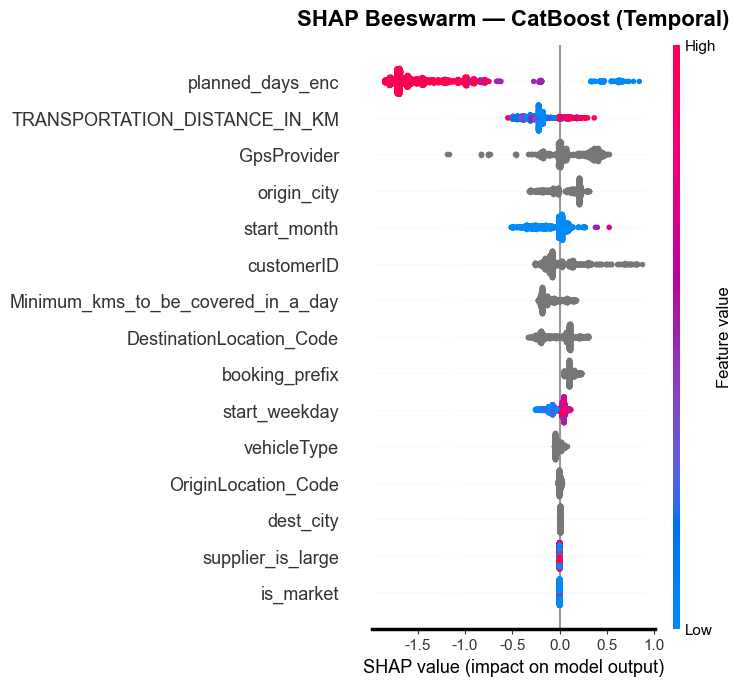

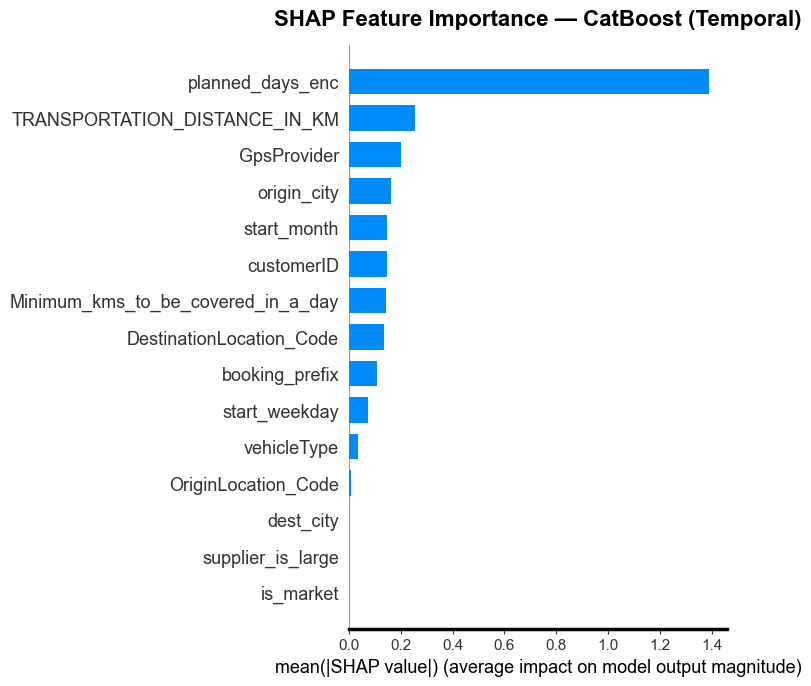

In [9]:

# ═══════════════════════════════════════════
#  1. CatBoost SHAP (best params, temporal split)
# ═══════════════════════════════════════════
cb = _create_model('CatBoost', spw_t)
cb.fit(X_train_xgb, y_train_t, cat_features=XGB_CAT_COLS)
cb_auc = roc_auc_score(y_test_t, cb.predict_proba(X_test_xgb)[:, 1])
print(f'CatBoost AUC (temporal): {cb_auc*100:.2f}%')
imp_cb, shap_v_cb, exp_cb = compute_shap_importance(cb, X_test_xgb, model_type='tree')

# Beeswarm
fig, ax = plt.subplots(figsize=(12, 7))
shap.summary_plot(shap_v_cb, X_test_xgb, plot_type='dot', show=False, max_display=15)
ax.set_title('SHAP Beeswarm — CatBoost (Temporal)', fontsize=16, fontweight='bold', pad=14)
fig.tight_layout(pad=2)
fig.savefig(str(FIGURES_SHAP / 'shap_dot_cb_time.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(str(FIGURES_SHAP / 'shap_dot_cb_time.png'), dpi=300, bbox_inches='tight')
plt.show()

# Bar
fig, ax = plt.subplots(figsize=(12, 6))
shap.summary_plot(shap_v_cb, X_test_xgb, plot_type='bar', show=False, max_display=15)
ax.set_title('SHAP Feature Importance — CatBoost (Temporal)', fontsize=16, fontweight='bold', pad=14)
fig.tight_layout(pad=2)
fig.savefig(str(FIGURES_SHAP / 'shap_bar_cb_time.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(str(FIGURES_SHAP / 'shap_bar_cb_time.png'), dpi=300, bbox_inches='tight')
plt.show()

Classification: TP=228  TN=951  FP=57  FN=135
--- TP - Correct delay ---
  BookingID: AEIBK2025741  |  Pred=0.954  |  Actual: Delayed


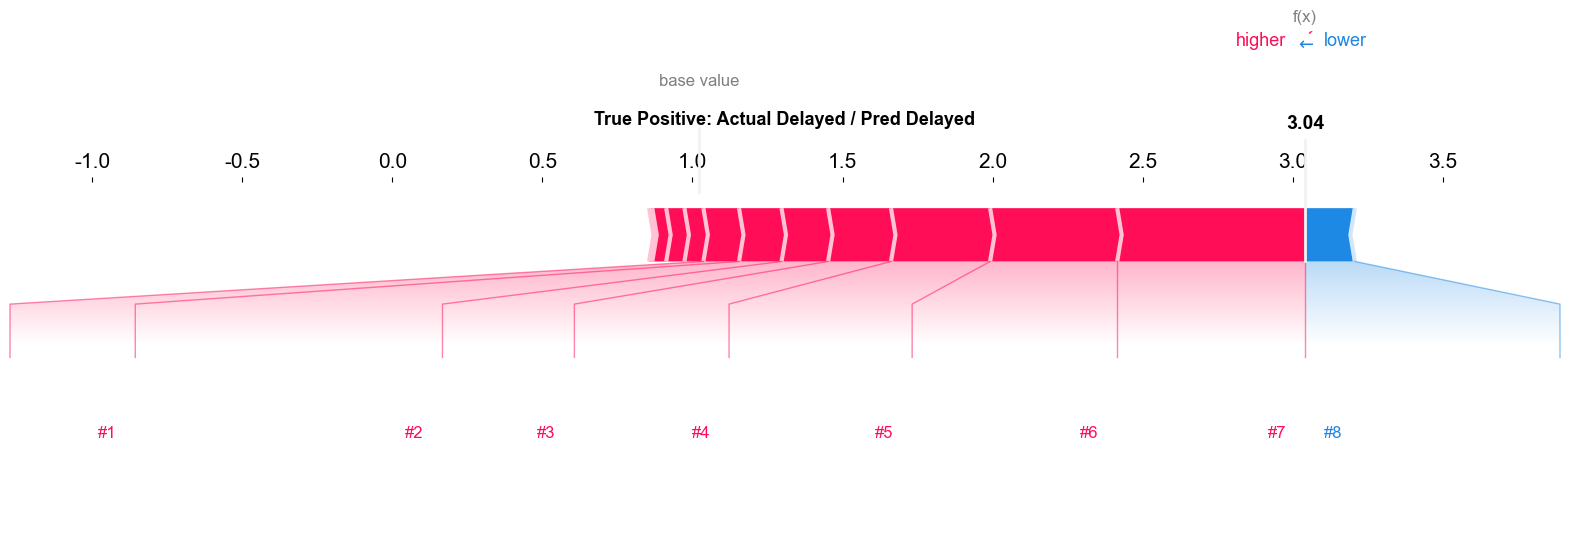


  Feature Reference:

    # 1  Distance (km)           = 1204.0        SHAP -0.1653  Pull down
    # 2  Planned days binned     = 0             SHAP +0.6264  Push up
    # 3  GPS Provider            = CONSENT TRACK  SHAP +0.4235  Push up
    # 4  Customer ID             = ERCEXPUNTG    SHAP +0.3302  Push up
    # 5  Booking prefix          = AEIBK         SHAP +0.2096  Push up
    # 6  Origin city             = PUNE          SHAP +0.1552  Push up
    # 7  Min daily km            = UNKNOWN       SHAP +0.1417  Push up
    # 8  Start month             = 8             SHAP +0.1187  Push up
    # 9  Dest code               = CHEUTHBALCCA2  SHAP +0.0631  Push up
    #10  Start weekday           = 2             SHAP +0.0608  Push up
    #11  Vehicle type            = 32 FT Single-Axle 7MT - HCV  SHAP +0.0463  Push up
    #12  Origin code             = PUNMAHERCCCB2  SHAP +0.0106  Push up
    #13  Dest city               = TIRUVALLUR    SHAP +0.0000  ~
    #14  Is large supplier       = 0    

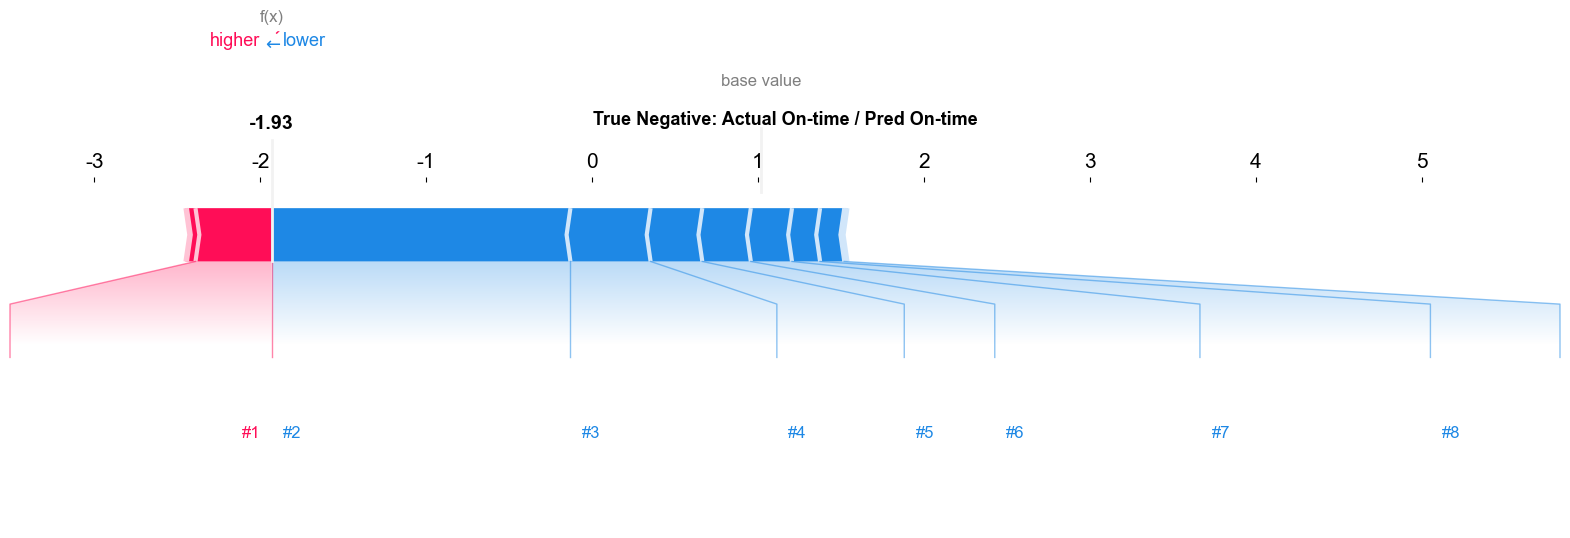


  Feature Reference:

    # 1  Origin code             = COIPERTVSHUA3  SHAP -0.0085  ~
    # 2  Vehicle type            = 1.5 MT Pickup (Open Body)  SHAP -0.0105  Pull down
    # 3  Customer ID             = ALLEXCHE45    SHAP -0.1458  Pull down
    # 4  Min daily km            = UNKNOWN       SHAP -0.1692  Pull down
    # 5  Dest code               = HOSHOSALLCCA3  SHAP -0.2483  Pull down
    # 6  Start month             = 8             SHAP -0.2925  Pull down
    # 7  Origin city             = COIMBATORE    SHAP -0.3117  Pull down
    # 8  Distance (km)           = 400.0         SHAP -0.4831  Pull down
    # 9  Planned days binned     = 2             SHAP -1.8016  Pull down
    #10  GPS Provider            = CONSENT TRACK  SHAP +0.4584  Push up
    #11  Booking prefix          = AEIBK         SHAP +0.0517  Push up
    #12  Start weekday           = 5             SHAP +0.0086  ~
    #13  Dest city               = KRISHNAGIRI   SHAP +0.0000  ~
    #14  Is large supplier       = 0    

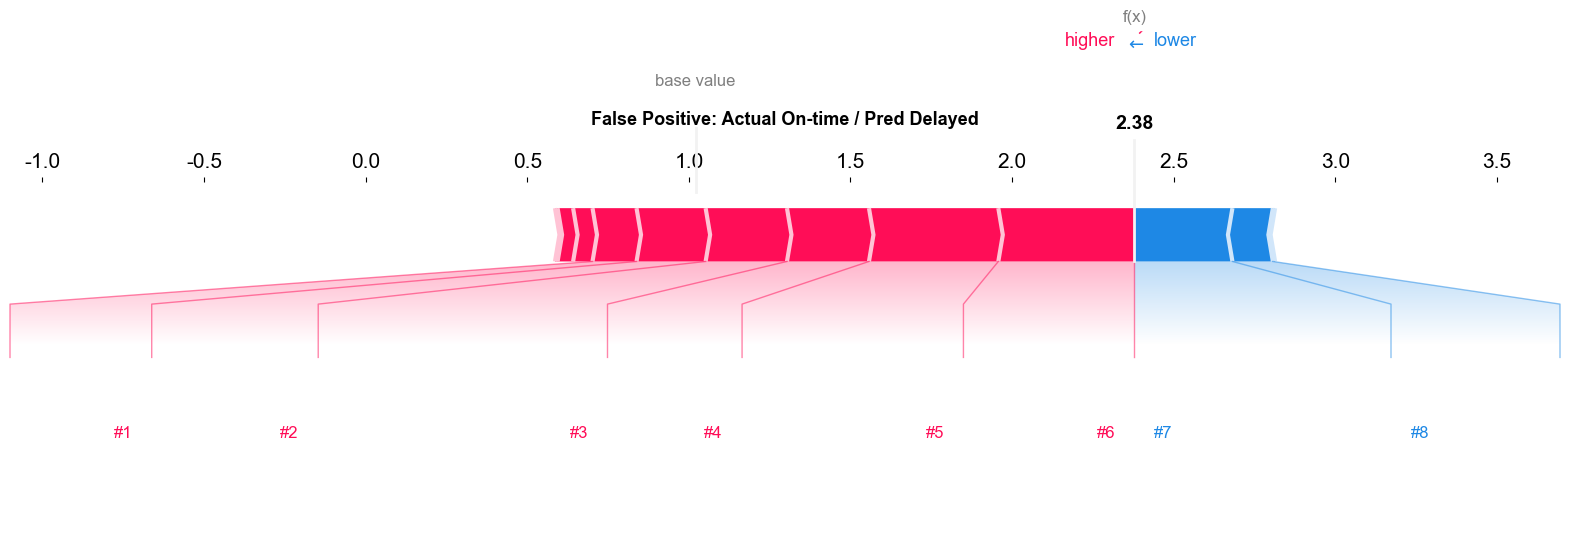


  Feature Reference:

    # 1  Min daily km            = UNKNOWN       SHAP -0.0068  ~
    # 2  Customer ID             = ERCEXPUNTG    SHAP -0.1251  Pull down
    # 3  Distance (km)           = 1177.0        SHAP -0.3032  Pull down
    # 4  Planned days binned     = 0             SHAP +0.4211  Push up
    # 5  GPS Provider            = CONSENT TRACK  SHAP +0.4002  Push up
    # 6  Start month             = 9             SHAP +0.2537  Push up
    # 7  Dest code               = GURJAIPUBTPA4  SHAP +0.2516  Push up
    # 8  Booking prefix          = AEIBK         SHAP +0.2138  Push up
    # 9  Origin city             = PUNE          SHAP +0.1362  Push up
    #10  Start weekday           = 3             SHAP +0.0600  Push up
    #11  Vehicle type            = 32 FT Single-Axle 7MT - HCV  SHAP +0.0480  Push up
    #12  Origin code             = PUNMAHERCCCB2  SHAP +0.0081  ~
    #13  Dest city               = JAIPUR        SHAP +0.0000  ~
    #14  Is large supplier       = 0             S

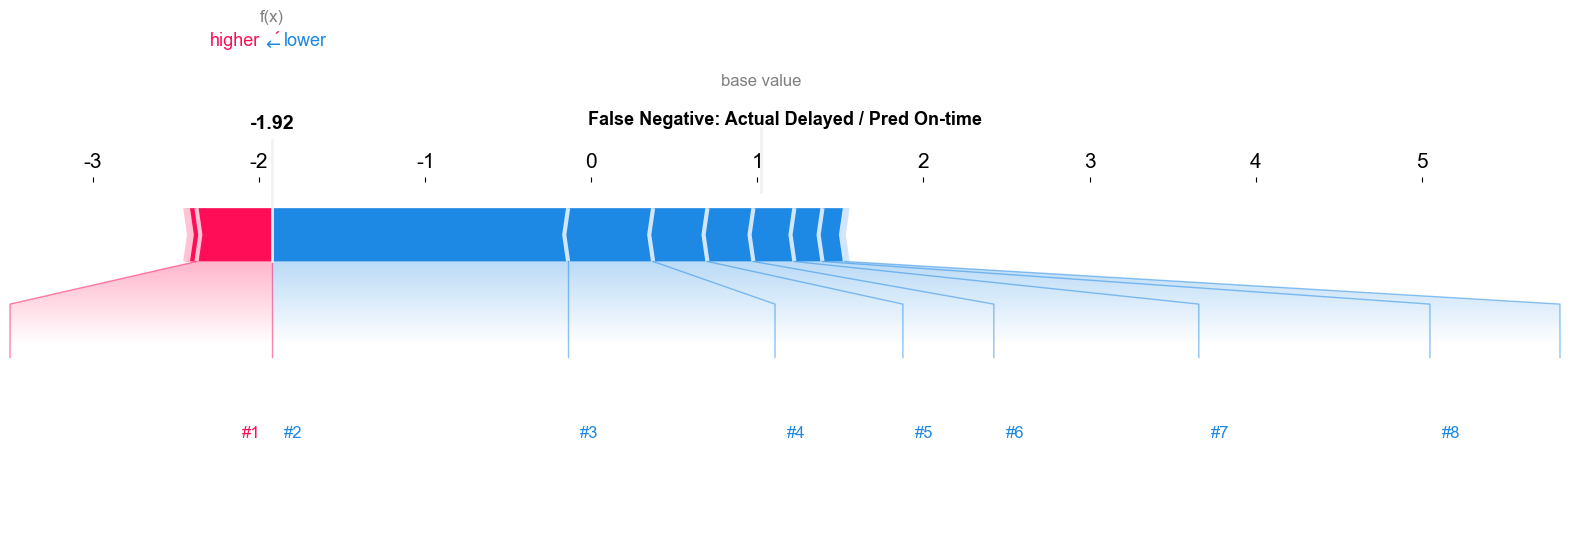


  Feature Reference:

    # 1  Vehicle type            = 1.5 MT Pickup (Open Body)  SHAP -0.0065  ~
    # 2  Origin code             = COIPERTVSHUA3  SHAP -0.0095  ~
    # 3  Customer ID             = ALLEXCHE45    SHAP -0.1351  Pull down
    # 4  Min daily km            = UNKNOWN       SHAP -0.1692  Pull down
    # 5  Dest code               = CHEENNALLCCA1  SHAP -0.2466  Pull down
    # 6  Start month             = 8             SHAP -0.2768  Pull down
    # 7  Origin city             = COIMBATORE    SHAP -0.3272  Pull down
    # 8  Distance (km)           = 530.0         SHAP -0.5115  Pull down
    # 9  Planned days binned     = 2             SHAP -1.7830  Pull down
    #10  GPS Provider            = CONSENT TRACK  SHAP +0.4544  Push up
    #11  Booking prefix          = AEIBK         SHAP +0.0517  Push up
    #12  Start weekday           = 3             SHAP +0.0159  Push up
    #13  Dest city               = TIRUVALLUR    SHAP +0.0000  ~
    #14  Is large supplier       = 0      

In [10]:
# ════════════════════════════════════════════════════════════════
#  Fig 2-5: SHAP Force Plot for 4 prediction types (standard)
#  TP / TN / FP / FN — feature push/pull + order details
#  Uses shap.force_plot, replaces labels with #N,
#  adjusts y-positions to avoid overlap with E[f(x)].
# ════════════════════════════════════════════════════════════════

from logistics_delay.interpretation.shap_analysis import render_force_plot, BUSINESS_MAP

# -- Prediction breakdown --
y_pred_proba = cb.predict_proba(X_test_xgb)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

tp = (y_test_t.values == 1) & (y_pred == 1)
tn = (y_test_t.values == 0) & (y_pred == 0)
fp = (y_test_t.values == 0) & (y_pred == 1)
fn = (y_test_t.values == 1) & (y_pred == 0)

print(f'Classification: TP={tp.sum()}  TN={tn.sum()}  FP={fp.sum()}  FN={fn.sum()}')

shap_v = shap_v_cb
base_value = exp_cb.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = base_value[1]

def _pick_rep(mask, prefer_delay=True):
    idx_arr = np.where(mask)[0]
    if len(idx_arr) == 0:
        return None
    total = shap_v[idx_arr].sum(axis=1)
    if prefer_delay:
        return idx_arr[np.argmax(total)]
    else:
        return idx_arr[np.argmin(total)]

idx_tp = _pick_rep(tp, prefer_delay=True)
idx_tn = _pick_rep(tn, prefer_delay=False)
idx_fp = _pick_rep(fp, prefer_delay=True)
idx_fn = _pick_rep(fn, prefer_delay=False)

categories = [
    ('TP - Correct delay', 'True Positive: Actual Delayed / Pred Delayed', idx_tp, 'force_plot_tp'),
    ('TN - Correct on-time', 'True Negative: Actual On-time / Pred On-time', idx_tn, 'force_plot_tn'),
    ('FP - False delay', 'False Positive: Actual On-time / Pred Delayed', idx_fp, 'force_plot_fp'),
    ('FN - False on-time', 'False Negative: Actual Delayed / Pred On-time', idx_fn, 'force_plot_fn'),
]

# ================================================================
#  Generate 4 force plots
# ================================================================

for subtitle, title, idx, fname in categories:
    if idx is None:
        print(f'[Skip] {subtitle} - no samples')
        continue

    print(f'--- {subtitle} ---')
    print(f'  BookingID: {test_ids[idx]}  |  '
          f'Pred={y_pred_proba[idx]:.3f}  |  '
          f'Actual: {"Delayed" if y_test_t.values[idx] else "On-time"}')

    blocks = render_force_plot(
        shap_values_1d=shap_v[idx],
        base_value=base_value,
        feature_values=X_test_xgb.iloc[idx],
        feature_names=FEATURES_XGB,
        title=title,
        save_path=FIGURES_SHAP / fname,
        business_map=BUSINESS_MAP,
    )

    # Reference table
    print()
    print('  Feature Reference:\n')
    for b in blocks:
        n = b['number']
        name = b['display_name']
        val = b['value']
        sval = b['shap']
        arrow = 'Push up' if sval > 0.01 else ('Pull down' if sval < -0.01 else '~')
        print(f'    #{n:2d}  {name:<22s}  = {str(val):<12s}  SHAP {sval:+.4f}  {arrow}')
    print()
    print('-' * 90)
    print()

In [11]:
print('=' * 60)
print('  SHAP Analysis Complete — CatBoost (Temporal Split)')
print('=' * 60)
print(f'CatBoost  AUC={cb_auc*100:.2f}%')
print()
top3_cb = imp_cb.head(3)['feature'].tolist()
print(f'CatBoost  Top-3: {top3_cb}')

  SHAP Analysis Complete — CatBoost (Temporal Split)
CatBoost  AUC=83.49%

CatBoost  Top-3: ['planned_days_enc', 'TRANSPORTATION_DISTANCE_IN_KM', 'GpsProvider']
